# Learning Magic‑Formula Parameters with a Conditional DDIM
This notebook shows **a minimal working example** of using a *conditional Denoising Diffusion Implicit Model (DDIM)* to learn the four parameters (B, C, D, E) of the Pacejka *Magic Formula* for the friction–slip curve of an anti‑lock braking system (ABS), **conditioned on five noisy measurements**.

⚠️ *Because we only condition on five data points, this is purely an educational toy example—not production code.*

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torch.optim import lr_scheduler
import torch.optim as optim

n_cond = 10  # number of samples to act as the condition for the diffusion model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [24]:
def magic_formula(slip, params):
    """Return mu given slip (tensor) and params = (B,C,D,E)."""
    B, C, D, E = params.to(device).unbind(-1)
    return D * torch.sin(C * torch.atan(B * slip - E * (B * slip - torch.atan(B * slip)) ) )


In [25]:
def make_batch(batch_size=64, n_cond=n_cond, noise_std=0.05, slip_range=(0.0, 1.0)):
    """Generate a batch of (params, condition) pairs.

    * params: true (B,C,D,E) ∈ ℝ⁴
    * condition: noisy (slip, mu) pairs generated from each set of BCDE
    """
    # Sample random ground‑truth parameters from realistic ranges
    B = torch.empty(batch_size, 1, device=device).uniform_(4.0, 12.0)
    C = torch.empty(batch_size, 1, device=device).uniform_(1.0, 2.0)
    D = torch.empty(batch_size, 1, device=device).uniform_(0.1, 1.9)
    E = torch.empty(batch_size, 1, device=device).uniform_(-1.0, 1.0)
    params = torch.cat([B, C, D, E], dim=1)

    # Generate n_cond pairs of (slip, mu) for each BCDE
    slip = (torch.rand(batch_size, n_cond, device=device)) * (slip_range[1] - slip_range[0])  + slip_range[0]
    # slip = torch.linspace(slip_range[0], slip_range[1], n_cond).repeat(batch_size, 1)
    sorted_slip, _ = torch.sort(slip, dim=1)
    mu = magic_formula(sorted_slip, params.unsqueeze(1).expand(-1, n_cond, -1))
    mu_noisy = mu + noise_std * torch.randn_like(mu)

    cond = torch.cat([sorted_slip, mu_noisy], dim=-1).reshape(batch_size, 2, -1)
    return params.to(device), cond.to(device)


/var/folders/50/2xnlv1wx4_91lvzqtbrvx_yc0000gn/T/ipykernel_18297/3270393090.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


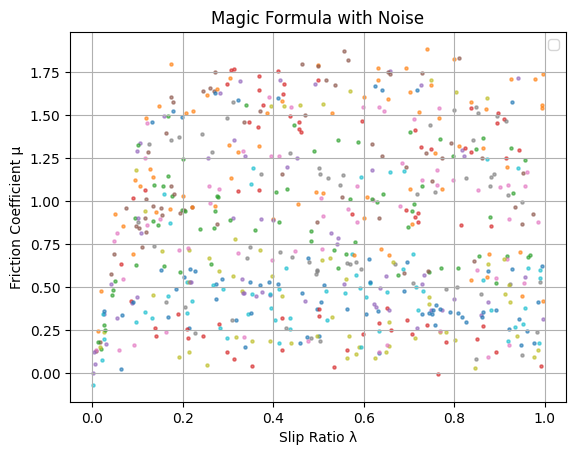

In [26]:
data_param, data_slip = make_batch()
for i in range(data_param.shape[0]):
    slips, mu_noisy = data_slip[i, 0, :], data_slip[i, 1, :]

    # Plot the Magic Formula
    plt.scatter(slips.cpu(), mu_noisy.cpu(), alpha=0.6, s=5)

plt.xlabel('Slip Ratio λ')
plt.ylabel('Friction Coefficient μ')
plt.title('Magic Formula with Noise')
plt.grid(True)
plt.legend()
plt.show()

In [27]:
## Diffusion schedule
T = 1000
beta_start, beta_end = 1e-4, 0.025
betas = torch.linspace(beta_start, beta_end, T, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)


## Determining the scale and shift parameters used to tranform B,C,D,E in [0,1]
range_b = (4.0, 12.0)
range_c = (1.0, 2.0)
range_d = (0.1, 1.9)
range_e = (-1.0, 1.0)
scale = torch.tensor([range_b[1] - range_b[0], range_c[1] - range_c[0],
                      range_d[1] - range_d[0], range_e[1] - range_e[0]]).to(data_param.device)
shift = torch.tensor([range_b[0], range_c[0],
                      range_d[0], range_e[0]]).to(data_param.device)


In [28]:
def q_sample(x0, t, noise=None):
    """Diffusion forward process q(x_t | x_0)."""
    if noise is None:
        noise = torch.randn_like(x0, device=device)
    sqrt_alphas_cumprod = (alphas_cumprod[t]**0.5).unsqueeze(1).to(device).expand_as(x0)
    sqrt_one_minus_alphas_cumprod = ((1 - alphas_cumprod[t])**0.5).unsqueeze(1).to(device).expand_as(x0)

    return sqrt_alphas_cumprod * x0 + sqrt_one_minus_alphas_cumprod * noise, noise


In [29]:

class CondMLP(nn.Module):
    def __init__(self, cond_dim=2*n_cond, x_dim=4, hidden1=128, hidden2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim + cond_dim + 1, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.Sigmoid(),
            nn.Linear(hidden2, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, x_dim)
        )
        # self.net = nn.Sequential(
        #     nn.Linear(x_dim + cond_dim + 1, 3200),
        #     nn.Sigmoid(),
        #     # nn.Linear(hidden1, hidden2),
        #     # nn.ReLU(),
        #     # nn.Linear(hidden2, hidden2),
        #     # nn.ReLU(),
        #     nn.Linear(3200, x_dim)
        # )
    def forward(self, x_t, t, cond):
        # Embed timestep as (t / T) to 1‑D scalar
        t_embed = (t.float() / T).unsqueeze(-1)
        inp = torch.cat([x_t, cond, t_embed], dim=-1)
        return self.net(inp)


In [30]:
def ddim_sample(model, cond, n_steps=1000, eta=0.0):
  x = torch.randn(cond.shape[0], 4, device=cond.device)
  step_size = T // n_steps
  for i in range(T-1, -1, -step_size):
    t = torch.full((cond.size(0),), i, device=cond.device, dtype=torch.long)
    noise_pred = model(x, t, cond)

    alpha_bar = alphas_cumprod[i]
    i_prev = max(i - step_size, 0)
    alpha_bar_prev = alphas_cumprod[i_prev]

    # Predict x_0
    x0_pred = (x - torch.sqrt(1 - alpha_bar) * noise_pred) / torch.sqrt(alpha_bar) * torch.sqrt(alpha_bar_prev)


    # DDIM coefficients
    sigma = 0.0
    if eta > 0:
      sigma = (
        eta
        * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar))
        * torch.sqrt(1 - alpha_bar / alpha_bar_prev)
      )

    dir_xt = torch.sqrt(1 - alpha_bar_prev - sigma**2) * noise_pred
    x = dir_xt + x0_pred
    if eta > 0:
      x = x + sigma * torch.randn_like(x)
  return x0_pred


In [31]:
model = CondMLP().to(device)

epochs1, batch_size1 = 100000, 1024
epochs2, inner_epochs, batch_size2, n_cond2 = 100000, 5, 1024, 30

# Initialize a learning rate scheduler (e.g., StepLR)
optimizer1 = torch.optim.RMSprop(model.parameters(), lr=1e-3)
scheduler1 = lr_scheduler.StepLR(optimizer1, step_size=epochs1/3, gamma=0.1)

optimizer2 = torch.optim.Adam(model.parameters(), lr=1e-5 )
scheduler2 = lr_scheduler.StepLR(optimizer2, step_size=epochs2/3, gamma=0.1)
l1_loss = nn.L1Loss()

In [32]:
sample_size = 1000

@torch.no_grad()
def draw(model):
  slips = torch.linspace(0, 1, sample_size, device=device)
  slips_np = slips.detach().cpu().numpy()
  fig, axes = plt.subplots(1, 10, figsize=(40, 4))
  for i in range(10):
      # Generate new ground-truth parameters and noisy condition
      true_params_i, cond_test_i = make_batch(1, n_cond, noise_std=0.03)
      slips_i, mu_true = cond_test_i[:, 0, :], cond_test_i[:, 1, :]
      # Estimate parameters using DDIM
      est_params_i = ddim_sample(model, cond_test_i.reshape(1, -1), n_steps=T).squeeze()

      # Compute mu for a range of slips
      mu_true_i = magic_formula(slips, true_params_i).detach().cpu().numpy()
      mu_est_i = magic_formula(slips, est_params_i).detach().cpu().numpy()
      # Plot
      axes[i].plot(slips_np, mu_true_i, label='True μ')
      axes[i].plot(slips_np, mu_est_i, label='Estimated μ')
      axes[i].scatter(slips_i.detach().cpu().numpy(), mu_true.detach().cpu().numpy(), label='Conditions', s=10)
      axes[i].set_xlabel('Slip Ratio λ')
      axes[i].set_ylabel('Friction Coefficient μ')
      axes[i].set_title(f'Magic Formula: Example {i+1}')
      axes[i].legend()
      axes[i].grid(True)
  plt.tight_layout()
  plt.show()
  
  
  fig, axes = plt.subplots(1, 5, figsize=(15, 5))

  # Generate new ground-truth parameters and noisy condition
  true_params, cond_test = make_batch(sample_size, n_cond, noise_std=0.0)
  slips, mu_true = cond_test[:, 0, :], cond_test[:, 1, :]
  # Estimate parameters using DDIM
  est_params = ddim_sample(model, cond_test.reshape(sample_size, -1), n_steps=T).squeeze()

  bs_true = true_params[:, 0]
  cs_true = true_params[:, 1]
  ds_true = true_params[:, 2]
  es_true = true_params[:, 3]

  bs_pred = est_params[:, 0]
  cs_pred = est_params[:, 1]
  ds_pred = est_params[:, 2]
  es_pred = est_params[:, 3]


  for j in range(4):
    axes[j].scatter(true_params[:, j].detach().cpu().numpy(), est_params[:, j].detach().cpu().numpy(), alpha=0.5, s=5)
    axes[j].set_xlabel(f'True Param {j}')
    axes[j].set_ylabel(f'Estimated Param {j}')
    axes[j].set_title(f'Param {j} Estimation')
    axes[j].grid(True)
  
  axes[0].set_xlim(range_b[0], range_b[1])
  axes[0].set_ylim(range_b[0], range_b[1])
  axes[1].set_xlim(range_c[0], range_c[1])
  axes[1].set_ylim(range_c[0], range_c[1])
  axes[2].set_xlim(range_d[0], range_d[1])
  axes[2].set_ylim(range_d[0], range_d[1])
  axes[3].set_xlim(range_e[0], range_e[1])  
  axes[3].set_ylim(range_e[0], range_e[1])
  
  axes[4].scatter(bs_true * cs_true * ds_true, bs_pred * cs_pred * ds_pred, s=10)
  axes[4].set_xlabel(f'True BCD')
  axes[4].set_ylabel(f'Estimated BCD')
  axes[4].set_title(f'BCD Estimation')
  axes[4].grid(True)
  axes[4].set_xlim(0, 40)
  axes[4].set_ylim(0, 40)

  # plt.legend()
  plt.show()

  print("b r2:", 1 - F.mse_loss(bs_pred, bs_true) / torch.var(bs_true))
  print("c r2:", 1 - F.mse_loss(cs_pred, cs_true) / torch.var(cs_true))
  print("d r2:", 1 - F.mse_loss(ds_pred, ds_true) / torch.var(ds_true))
  print("e r2:", 1 - F.mse_loss(es_pred, es_true) / torch.var(es_true))

step   100 | loss1 3.4645e-01 | loss2 4.3780e+13
step   200 | loss1 2.9668e-01 | loss2 3.1903e+13
step   300 | loss1 3.2053e-01 | loss2 2.8775e+13
step   400 | loss1 2.9580e-01 | loss2 3.0803e+13
step   500 | loss1 2.3330e-01 | loss2 5.0890e+11


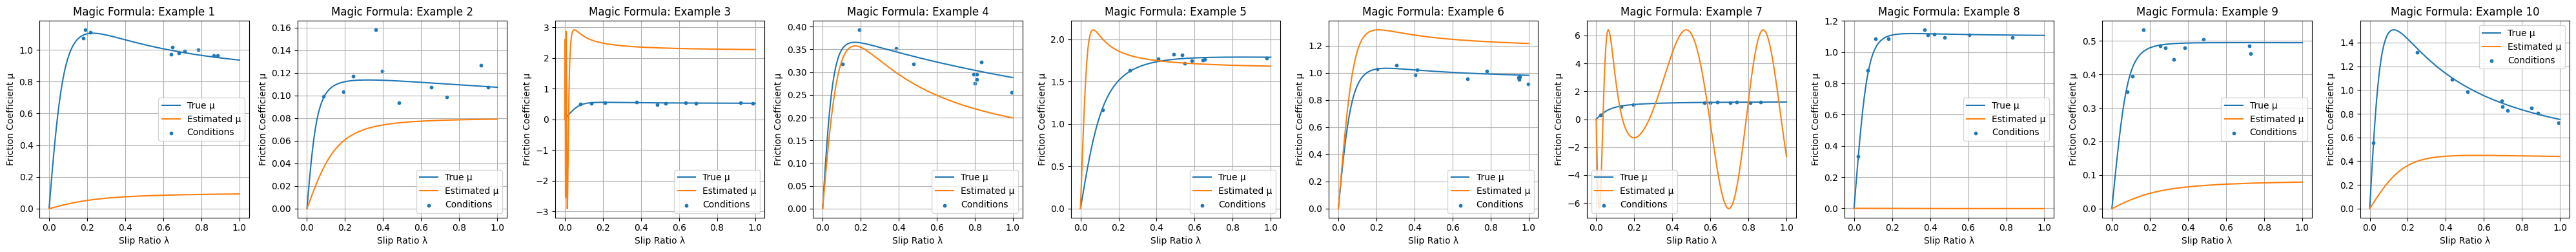

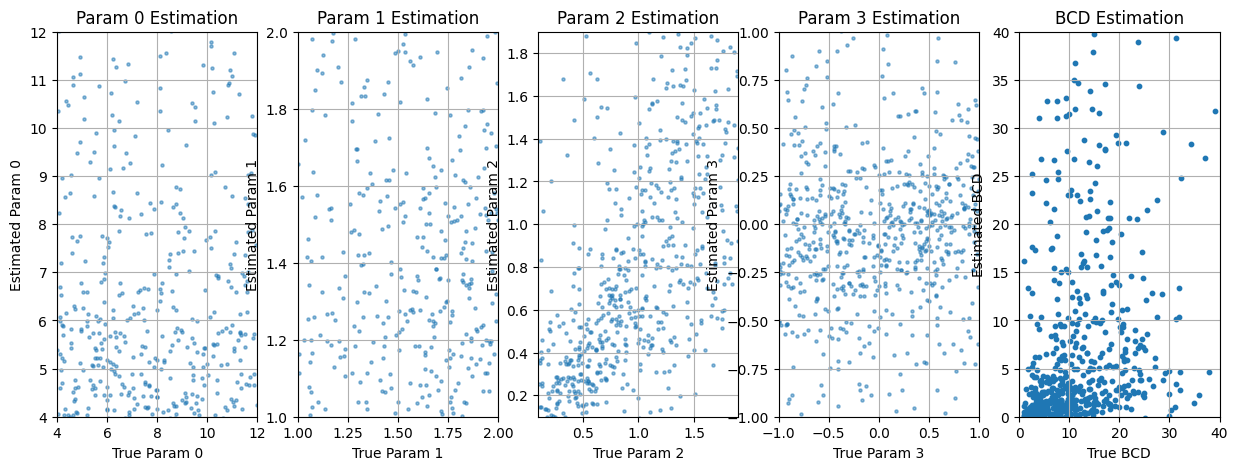

b r2: tensor(-3431.6062)
c r2: tensor(-6424.9473)
d r2: tensor(-2407.9617)
e r2: tensor(-1958.8844)
step   600 | loss1 3.2725e-01 | loss2 2.8141e+12
step   700 | loss1 2.3242e-01 | loss2 3.0221e+10
step   800 | loss1 2.4355e-01 | loss2 2.1212e+11
step   900 | loss1 2.2234e-01 | loss2 5.3425e+11
step  1000 | loss1 2.1776e-01 | loss2 6.1648e+10


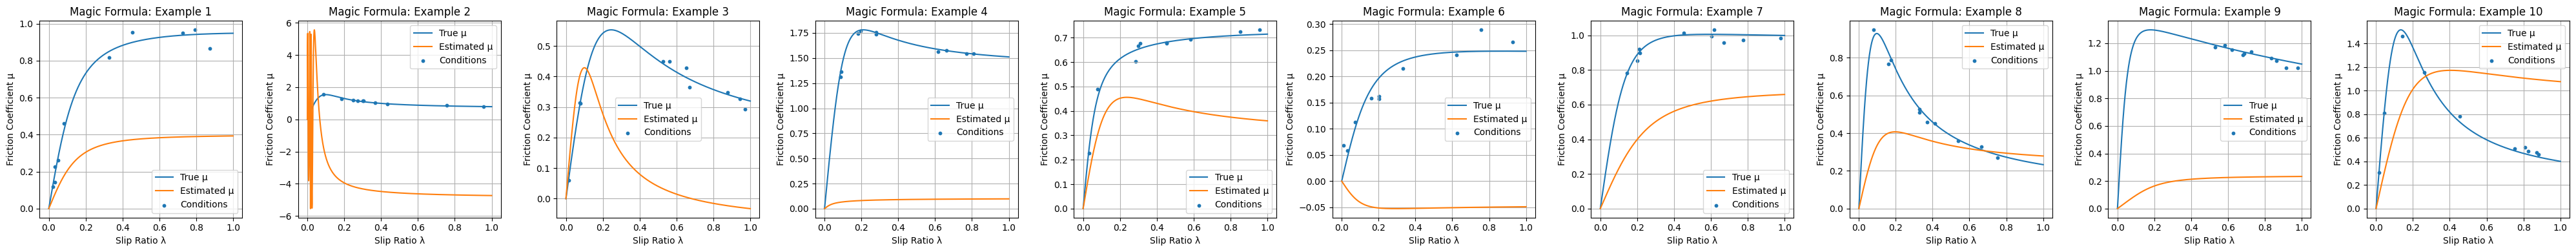

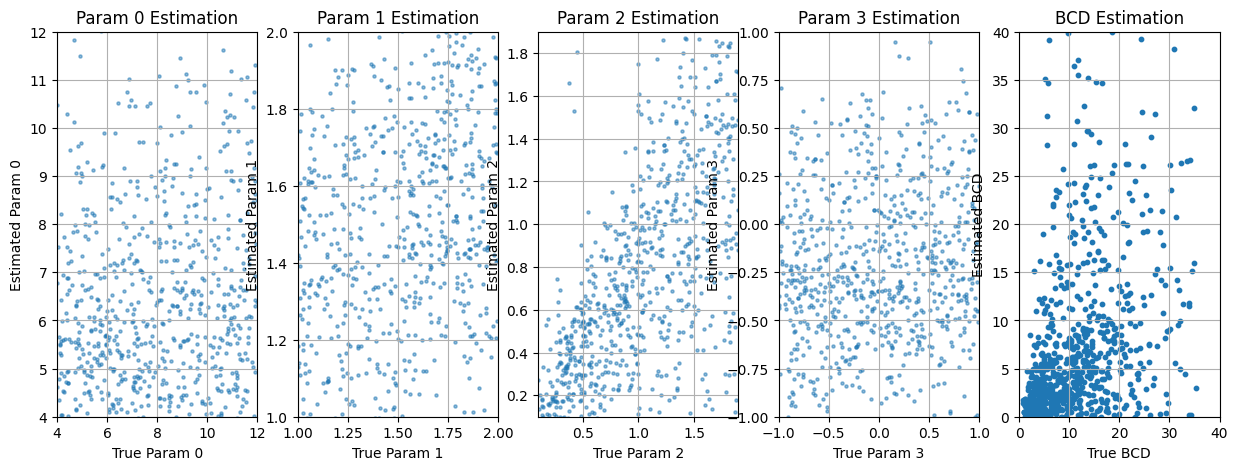

b r2: tensor(-902.6664)
c r2: tensor(-1308.1755)
d r2: tensor(-399.7923)
e r2: tensor(-298.4829)
step  1100 | loss1 2.2932e-01 | loss2 3.4183e+10
step  1200 | loss1 2.3041e-01 | loss2 1.1046e+10
step  1300 | loss1 2.0004e-01 | loss2 1.1448e+11
step  1400 | loss1 2.3929e-01 | loss2 4.7839e+09
step  1500 | loss1 2.2142e-01 | loss2 6.7475e+09


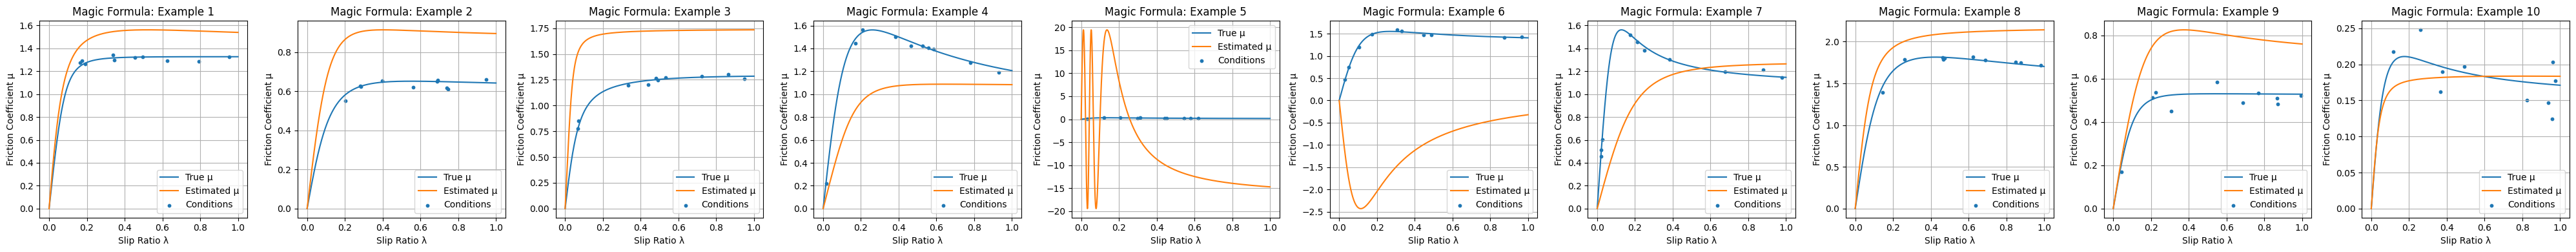

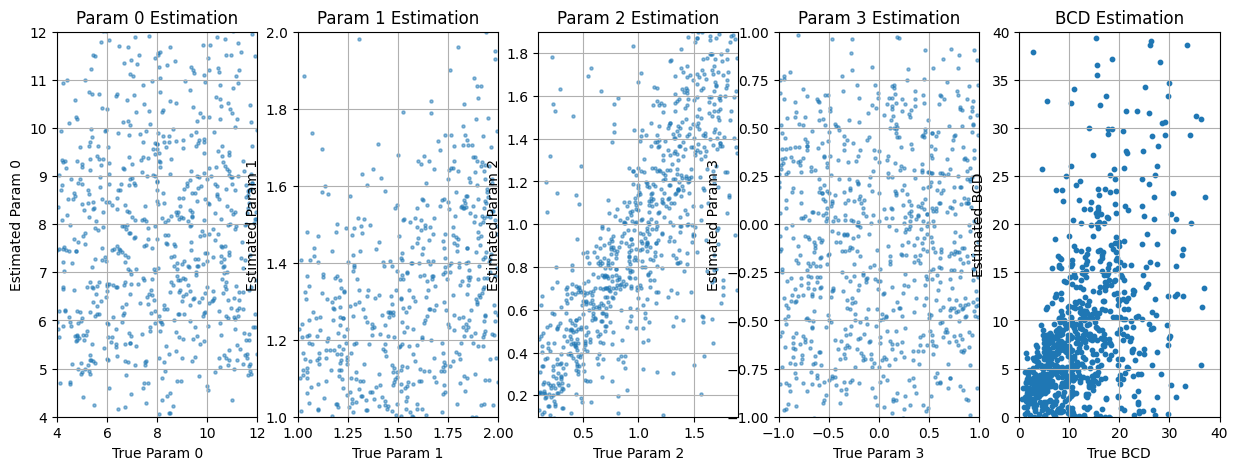

b r2: tensor(-230.6391)
c r2: tensor(-1146.1144)
d r2: tensor(-254.9547)
e r2: tensor(-120.8238)
step  1600 | loss1 2.2600e-01 | loss2 5.7336e+09
step  1700 | loss1 2.2388e-01 | loss2 1.1286e+10
step  1800 | loss1 2.2024e-01 | loss2 3.8504e+10
step  1900 | loss1 1.9996e-01 | loss2 3.9399e+09
step  2000 | loss1 1.9350e-01 | loss2 4.7777e+10


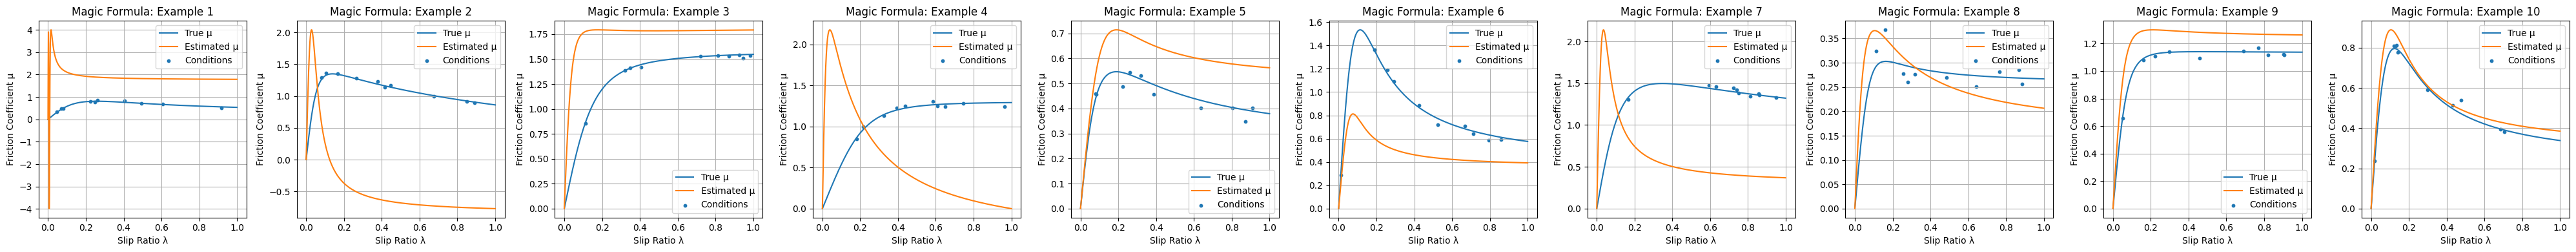

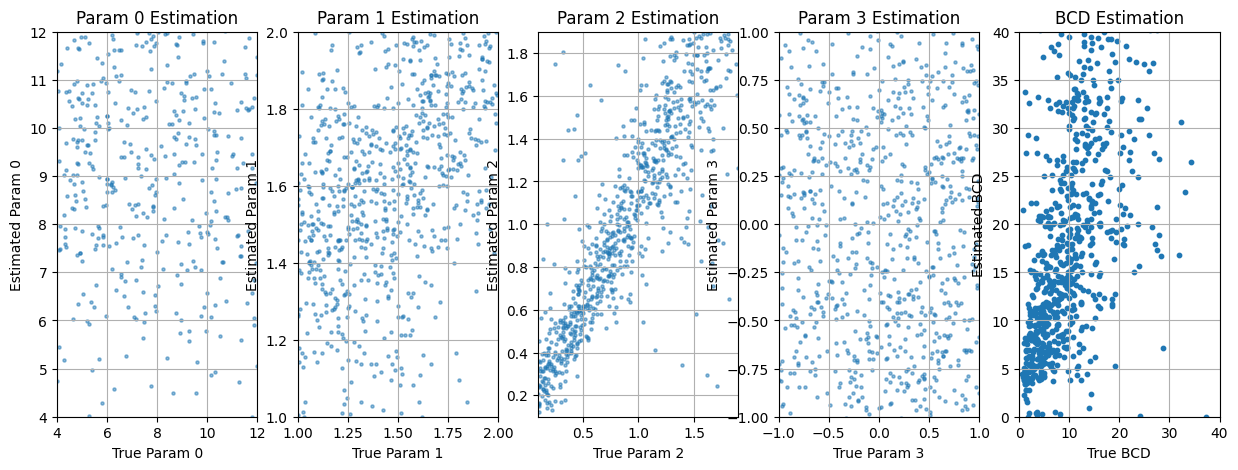

b r2: tensor(-367.4828)
c r2: tensor(-145.1194)
d r2: tensor(-155.2025)
e r2: tensor(-289.6127)
step  2100 | loss1 1.7580e-01 | loss2 1.1239e+09
step  2200 | loss1 1.8435e-01 | loss2 9.9363e+10
step  2300 | loss1 1.8999e-01 | loss2 4.0315e+09


In [ ]:
for step in range(1, epochs1+1):
  # Generating batches of params_0=(B,C,D,E),
  # cond=(slip, mu) pairs for each set of params, and time step t
  params_0, cond = make_batch(batch_size1, noise_std=0.03)
  slips, mu_true = cond[:, 0, :], cond[:, 1, :]
  t = torch.randint(0, T, (batch_size1,), device=device)

  # Generating the noisy params for time step t
  x_t, noise = q_sample(params_0, t)

  # forward process the model to generate an estimated noise
  noise_pred = model(x_t, t, cond.reshape(batch_size1, -1))

  loss1 = F.mse_loss(noise_pred, noise)

  optimizer1.zero_grad()
  loss1.backward()
  optimizer1.step()

  # Update the learning rate
  scheduler1.step()

  # if step % 10000 == 0:
  #   print(f"Optimizer1: step {step:5d} | loss {loss1.item():.4e}")

  if step % (epochs1 // epochs2) == 0:
    for _ in range(inner_epochs):
      params, cond = make_batch(batch_size2, noise_std=0.0)
      Bs, Cs, Ds, Es = params[:, 0], params[:, 1], params[:, 2], params[:, 3]
      BCDs = Bs * Cs * Ds

      # Estimate parameters using DDIM
      est_params = ddim_sample(model, cond.reshape(batch_size2, -1), n_steps=10).squeeze()
      est_Bs, est_Cs, est_Ds, est_Es = est_params[:, 0], est_params[:, 1], est_params[:, 2], est_params[:, 3]
      est_BCDs = est_Bs * est_Cs * est_Ds
      
      slips = torch.linspace(0, 1, n_cond2, device=device)
      mu_true = magic_formula(slips, params.unsqueeze(1).expand(-1, n_cond2, -1))
      mu_est = magic_formula(slips, est_params.unsqueeze(1).expand(-1, n_cond2, -1))
      
      shifted_est_params = (est_params - shift.T.repeat(batch_size2, 1)) / scale.T.repeat(batch_size2, 1)
      shifted_true_params = (params - shift.T.repeat(batch_size2, 1)) / scale.T.repeat(batch_size2, 1)
      
      mse_mu = F.mse_loss(mu_true, mu_est)
      mse_params = F.mse_loss(shifted_est_params, shifted_true_params)
      mse_BCDs = F.mse_loss(est_BCDs, BCDs)
      rel_Bs = F.relu(4.0 - est_Bs).mean() + F.relu(est_Bs - 12.0).mean()
      rel_Cs = F.relu(1.0 - est_Cs).mean() + F.relu(est_Cs - 2.0).mean()
      rel_Ds = F.relu(0.1 - est_Ds).mean() + F.relu(est_Ds - 1.9).mean()
      rel_Es = F.relu(-1.0 - est_Es).mean() + F.relu(est_Es - 1.0).mean()

      loss2 = mse_mu + mse_params + mse_BCDs + rel_Bs + rel_Cs + rel_Ds + rel_Es

      optimizer2.zero_grad()
      loss2.backward()
      optimizer2.step()

    scheduler2.step()

    if step % (100 * epochs1 // epochs2) == 0:
      print(f"step {step:5d} | loss1 {loss1.item():.4e} | loss2 {loss2.item():.4e}")
    
    if step % (500 * epochs1 // epochs2) == 0:
      plt.bar(range(7), [mse_mu.item(), mse_params.item(), mse_BCDs.item(),
                  rel_Bs.item(), rel_Cs.item(), rel_Ds.item(), rel_Es.item()])
      plt.xticks(range(7), ['mse_mu', 'mse_params', 'mse_BCDs', 'rel_Bs', 'rel_Cs', 'rel_Ds', 'rel_Es'])
      plt.ylabel('Loss')
      plt.title(f'Step {step}')
      plt.show()
      draw(model)



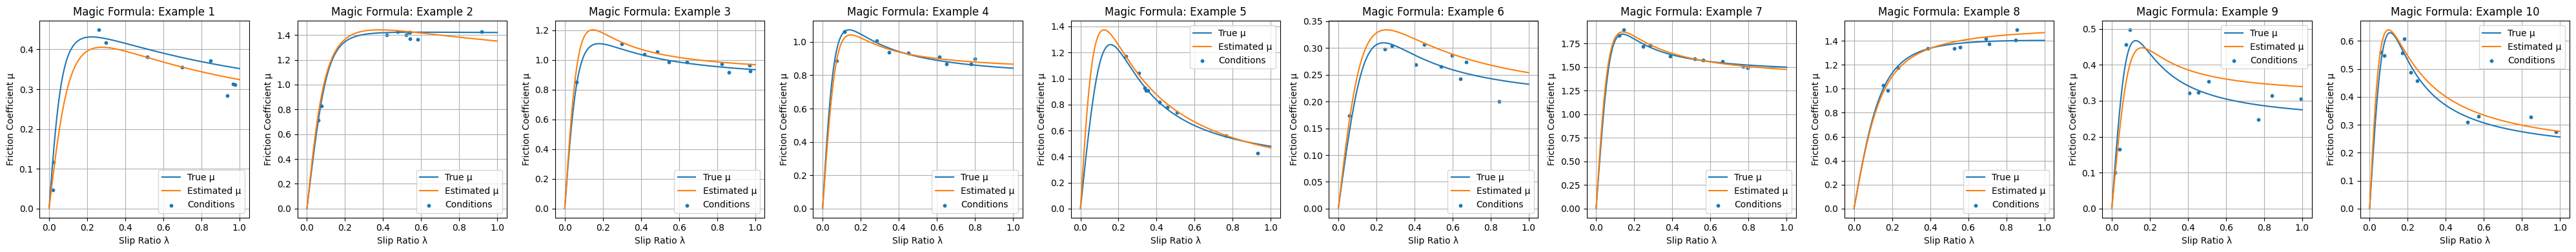

In [ ]:
sample_size = 1000
slips = np.linspace(0, 1, sample_size)
fig, axes = plt.subplots(1, 10, figsize=(40, 4))
for i in range(10):
    # Generate new ground-truth parameters and noisy condition
    true_params_i, cond_test_i = make_batch(1, n_cond, noise_std=0.03)
    slips_i, mu_true = cond_test_i[:, 0, :], cond_test_i[:, 1, :]
    # Estimate parameters using DDIM
    est_params_i = ddim_sample(model, cond_test_i.reshape(1, -1), n_steps=T).squeeze()

    # Compute mu for a range of slips
    mu_true_i = magic_formula(torch.tensor(slips, device=device), true_params_i).detach().cpu().numpy()
    mu_est_i = magic_formula(torch.tensor(slips, device=device), est_params_i).detach().cpu().numpy()
    # Plot
    axes[i].plot(slips, mu_true_i, label='True μ')
    axes[i].plot(slips, mu_est_i, label='Estimated μ')
    axes[i].scatter(slips_i.detach().cpu().numpy(), mu_true.detach().cpu().numpy(), label='Conditions', s=10)
    axes[i].set_xlabel('Slip Ratio λ')
    axes[i].set_ylabel('Friction Coefficient μ')
    axes[i].set_title(f'Magic Formula: Example {i+1}')
    axes[i].legend()
    axes[i].grid(True)
plt.tight_layout()
plt.show()

torch.Size([1000, 4]) torch.Size([1000, 4])
torch.Size([1000]) torch.Size([1000])


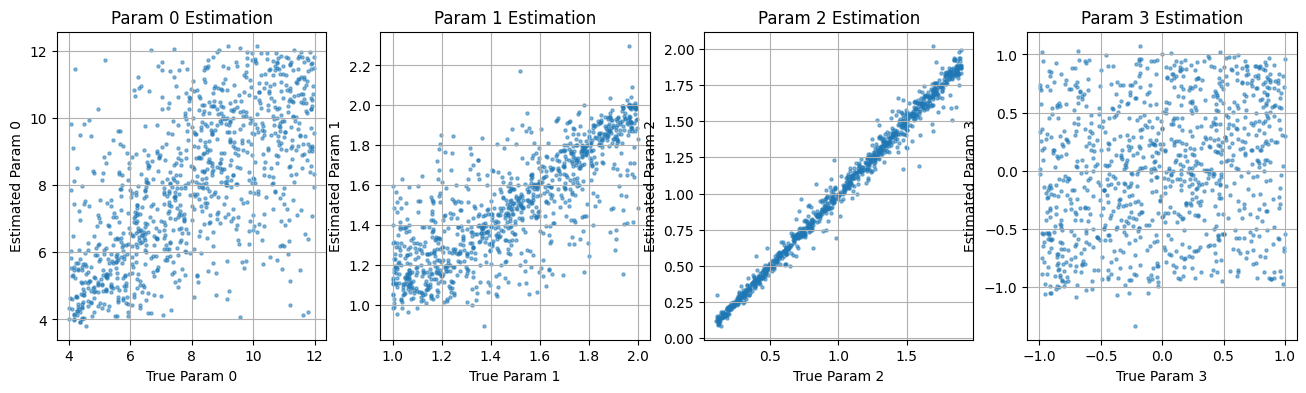

b r2: tensor(0.2930, grad_fn=<RsubBackward1>)
c r2: tensor(0.5829, grad_fn=<RsubBackward1>)
d r2: tensor(0.9886, grad_fn=<RsubBackward1>)
e r2: tensor(-0.5322, grad_fn=<RsubBackward1>)


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sample_size = 1000
# Generate new ground-truth parameters and noisy condition
true_params, cond_test = make_batch(sample_size, n_cond, noise_std=0.0)
slips, mu_true = cond_test[:, 0, :], cond_test[:, 1, :]
# Estimate parameters using DDIM
est_params = ddim_sample(model, cond_test.reshape(sample_size, -1), n_steps=T).squeeze()

print(true_params.shape, est_params.shape)

bs_true = true_params[:, 0]
cs_true = true_params[:, 1]
ds_true = true_params[:, 2]
es_true = true_params[:, 3]

bs_pred = est_params[:, 0]
cs_pred = est_params[:, 1]
ds_pred = est_params[:, 2]
es_pred = est_params[:, 3]

print(bs_true.shape, bs_pred.shape)


for j in range(4):
  axes[j].scatter(true_params[:, j].detach().cpu().numpy(), est_params[:, j].detach().cpu().numpy(), alpha=0.5, s=5)
  axes[j].set_xlabel(f'True Param {j}')
  axes[j].set_ylabel(f'Estimated Param {j}')
  axes[j].set_title(f'Param {j} Estimation')
  axes[j].grid(True)

# plt.legend()
plt.show()

print("b r2:", 1 - F.mse_loss(bs_pred, bs_true) / torch.var(bs_true))
print("c r2:", 1 - F.mse_loss(cs_pred, cs_true) / torch.var(cs_true))
print("d r2:", 1 - F.mse_loss(ds_pred, ds_true) / torch.var(ds_true))
print("e r2:", 1 - F.mse_loss(es_pred, es_true) / torch.var(es_true))

## Next Steps
* Increase the training data size and epochs for better accuracy.
* Replace the simple MLP with a richer network (e.g. sinusoidal timestep embedding, FiLM‑style conditional layers).
* Explore alternative conditioning tricks such as cross‑attention.
* Try other diffusion formulations (e.g. Score‑SDE, DPM‑Solver) for faster sampling.